In [2]:
# Librerías
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import backend as K

In [3]:

# ===== CAPA LEGENDRE =====
class LegendreLayer(layers.Layer):
    def __init__(self, units, degree, **kwargs):
        super(LegendreLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree

    def build(self, input_shape):
        self.w_leg = self.add_weight(
            shape=(self.degree, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="legendre_weights"
        )

    def call(self, inputs):
        x_leg = tf.cast(inputs, self.compute_dtype)

        p_n_minus_1_leg = tf.ones_like(x_leg)  # P0
        p_n_leg = x_leg                        # P1

        # Empezamos en grado 1
        output_leg = tf.matmul(p_n_leg, self.w_leg[0])

        for i in range(2, self.degree + 1):
            i_float_leg = tf.cast(i, self.compute_dtype)

            p_n_plus_1_leg = (
                (2.0 * i_float_leg - 1.0) * x_leg * p_n_leg
                - (i_float_leg - 1.0) * p_n_minus_1_leg
            ) / i_float_leg

            output_leg += tf.matmul(p_n_plus_1_leg, self.w_leg[i-1])

            p_n_minus_1_leg = p_n_leg
            p_n_leg = p_n_plus_1_leg

        return output_leg


In [4]:
# ===== FUNCIÓN DE PLOTEO =====
def plot_training_history_leg(history_leg):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history_leg.history['loss'], label='Pérdida entrenamiento')
    plt.plot(history_leg.history['val_loss'], label='Pérdida validación')
    plt.title('Pérdida')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history_leg.history['accuracy'], label='Precisión entrenamiento')
    plt.plot(history_leg.history['val_accuracy'], label='Precisión validación')
    plt.title('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()



In [5]:

# ===== DATOS =====
magic_gamma_telescope_leg = fetch_ucirepo(id=159)

X_leg = magic_gamma_telescope_leg.data.features 
y_leg = magic_gamma_telescope_leg.data.targets 

X_train_leg, X_test_leg, y_train_leg, y_test_leg = train_test_split( X_leg, y_leg, test_size=0.2, random_state=42)

scaler_leg = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled_leg = scaler_leg.fit_transform(X_train_leg)
X_test_scaled_leg = scaler_leg.transform(X_test_leg)

input_dim_leg = X_train_leg.shape[1]

y_train_leg = (y_train_leg == 'g').astype(int)
y_test_leg = (y_test_leg == 'g').astype(int)


In [6]:
# ===== MODELO =====
def PolynomialDenseCreator_leg(degree_leg):
    inputPoli_leg = keras.Input(shape=(input_dim_leg,))
    
    x_leg = LegendreLayer(32, degree=degree_leg)(inputPoli_leg)
    x_leg = layers.Activation('swish')(x_leg)
    x_leg = layers.Dense(16, activation='swish')(x_leg)
    
    outputPoli_leg = layers.Dense(2, activation='softmax')(x_leg)
    
    model_leg = keras.Model(
        inputs=inputPoli_leg,
        outputs=outputPoli_leg,
        name=f"Polynomial_Model_Degree_{degree_leg}_leg"
    )
    
    model_leg.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model_leg


In [7]:

# ===== PARÁMETROS =====
degree_leg = 4
epochs_leg = 120


def createEarlyStoppingCallback_leg(patience_leg=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_leg,
        restore_best_weights=True
    )



Entrenando Grado 4 (Legendre) ...
Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8020 - loss: 0.4448 - val_accuracy: 0.8348 - val_loss: 0.3817
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8485 - loss: 0.3662 - val_accuracy: 0.8446 - val_loss: 0.3618
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8534 - loss: 0.3538 - val_accuracy: 0.8525 - val_loss: 0.3513
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8578 - loss: 0.3472 - val_accuracy: 0.8482 - val_loss: 0.3552
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8566 - loss: 0.3417 - val_accuracy: 0.8574 - val_loss: 0.3451
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8570 - loss: 0.3393 - val_accuracy: 0.8581 - val_loss: 0.3364
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8598 - loss: 0.3354 - val_accuracy: 0.8591 - val_loss: 0.3386
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accurac

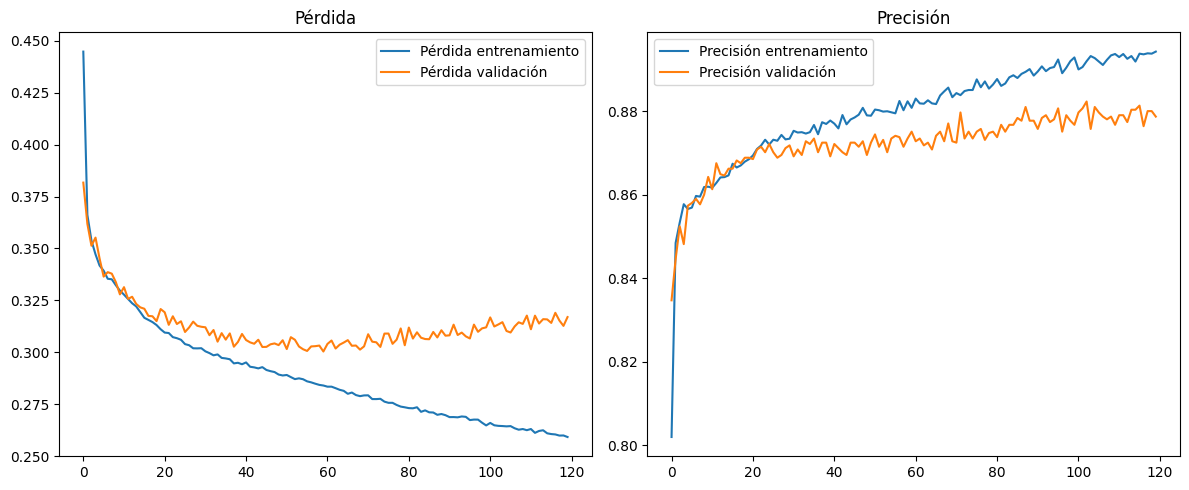

In [8]:

# ===== ENTRENAMIENTO =====
K.clear_session()

print("Entrenando Grado " + str(degree_leg) + " (Legendre) ...")

modeloTest_leg = PolynomialDenseCreator_leg(degree_leg)

history_leg = modeloTest_leg.fit(
    X_train_scaled_leg,
    y_train_leg,
    validation_split=0.2,
    epochs=epochs_leg,
    batch_size=32
)

print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree_leg} - Legendre)")

acc_leg = modeloTest_leg.evaluate(X_test_scaled_leg,y_test_leg,verbose=0)[1]

print("Accuracy en test: {:.6f}".format(acc_leg))

plot_training_history_leg(history_leg)